# 3. (Optional) Concordance

In [1]:
## Import libraries 
import os
import pandas as pd
import xgboost as xgb
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn.metrics as metrics
from sklearn.preprocessing import label_binarize

In [2]:
## Set working directory
# os.chdir("/Path/To/Your/Working Directory/") 
dir = 'Output/3-Concordance/'
os.makedirs(dir, exist_ok = True)

In [3]:
## Configuration
Label = ["PCD-P", "PCD-PN", "PCD-NF", "PCD-FA", "PCD-A"]
Mapping1 = {0: "PCD-P", 1: "PCD-PN", 2: "PCD-NF", 3: "PCD-FA", 4: "PCD-A"}
Mapping2 = {"PCD-P": 0, "PCD-PN": 1, "PCD-NF": 2, "PCD-FA": 3, "PCD-A": 4}
cmap = {"PCD-P": "#fdcc83", "PCD-PN": "#f6afb0", "PCD-NF": "#c27cd6", "PCD-FA": "#71b3a8", "PCD-A": "#6292b0"}

## 1. Prepare Data

In [4]:
## Get NMF-derived and predicted subtypes
Subtype_NMF = pd.read_csv('Data/CPTAC/PCD_Subtype_NMF.tsv', delimiter = '\t')
Subtype_NMF.rename(columns={'PCD_Subtype': 'PCD_Subtype_NMF'}, inplace = True)
Subtype_NMF = Subtype_NMF.set_index("ID_sample")
Prediction = pd.read_csv('Output/1-Infer_PCD_subtype/Prediction.tsv', delimiter = '\t')
Prediction.rename(columns={'PCD Subtype': 'PCD_Subtype_Predicted'}, inplace = True)
Prediction = Prediction.set_index("ID_sample")

Subtype = pd.merge(Subtype_NMF[["PCD_Subtype_NMF"]], Prediction, left_index = True, right_index = True, how = "left")
Subtype

,PCD_Subtype_NMF,PCD_Subtype_Predicted,Probability_PCD-P,Probability_PCD-PN,Probability_PCD-NF,Probability_PCD-FA,Probability_PCD-A,Max_Probability
ID_sample,,,,,,,,
25-R,PCD-FA,PCD-FA,0.007633,0.065130,0.030960,0.890813,0.005464,0.890813
350-R,PCD-P,PCD-P,0.982980,0.005903,0.007642,0.002936,0.000539,0.982980
345-R,PCD-A,PCD-A,0.113959,0.187869,0.009801,0.058748,0.629623,0.629623
349-R,PCD-FA,PCD-FA,0.001557,0.172546,0.055527,0.758645,0.011726,0.758645
26-R,PCD-A,PCD-PN,0.017353,0.782473,0.030431,0.138401,0.031342,0.782473
...,...,...,...,...,...,...,...,...
cb6b2cc0-d840-4968-837c-b3b833adfc52,PCD-PN,PCD-NF,0.057347,0.324236,0.561310,0.027846,0.029261,0.561310
da8993a8-d120-43a6-9a93-65aced75ed19,PCD-PN,PCD-PN,0.323390,0.608910,0.035760,0.025779,0.006161,0.608910
907d39d0-7e81-4d83-88dc-26cce0e7a0a1,PCD-PN,PCD-PN,0.031471,0.721626,0.161776,0.073419,0.011709,0.721626


In [5]:
PCD_Subtype_NMF = Subtype["PCD_Subtype_NMF"].copy().map(Mapping2)
PCD_Subtype_Predicted = Subtype["PCD_Subtype_Predicted"].copy().map(Mapping2)
Probability = Subtype[[c for c in Prediction.columns if c.startswith("Probability_")]].values

## 2. Performance

In [6]:
## Performance
Performance = {}
PCD_Subtype_NMF_class = label_binarize(PCD_Subtype_NMF, classes=[0, 1, 2, 3, 4])

# AUC
Performance["AUC_macro"] = metrics.roc_auc_score(PCD_Subtype_NMF_class, Probability, multi_class = 'ovr', average = 'macro')
for i in range(5):
    fpr, tpr, _ = metrics.roc_curve(
        PCD_Subtype_NMF_class[:, i], Probability[:, i], pos_label = 1
    )
    Performance[f"AUC_{i+1}"] = metrics.auc(fpr, tpr)
    Performance[f"PR_{i+1}"] = metrics.average_precision_score(
        PCD_Subtype_NMF_class[:, i], Probability[:, i], average = 'macro'
    )

# Classification Report
ClassRep = metrics.classification_report(PCD_Subtype_NMF, PCD_Subtype_Predicted, output_dict = True)
Performance["Accuracy"] = ClassRep["accuracy"]
Performance["Precision_macro"] = ClassRep["macro avg"]["precision"]
Performance["Recall_macro"] = ClassRep["macro avg"]["recall"]
Performance["F1-score_macro"] = ClassRep["macro avg"]["f1-score"]
for i in range(5):
    Performance[f"Precision_{i+1}"] = ClassRep[str(i)]["precision"]
    Performance[f"Recall_{i+1}"] = ClassRep[str(i)]["recall"]
    Performance[f"F1-score_{i+1}"] = ClassRep[str(i)]["f1-score"]

# Format output
Performance_overall = pd.DataFrame({
    "Accuracy": [Performance["Accuracy"]],
    "AUC_macro": [Performance["AUC_macro"]],
    "Precision_macro": [Performance["Precision_macro"]],
    "Recall_macro": [Performance["Recall_macro"]],
    "F1-score_macro": [Performance["F1-score_macro"]]
})
Performance_subtype = pd.DataFrame({
    "Subtype": Label,
    "AUC": [Performance[f"AUC_{i+1}"] for i in range(5)],
    "PR": [Performance[f"PR_{i+1}"] for i in range(5)],
    "Precision": [Performance[f"Precision_{i+1}"] for i in range(5)],
    "Recall": [Performance[f"Recall_{i+1}"] for i in range(5)],
    "F1-score": [Performance[f"F1-score_{i+1}"] for i in range(5)]
})
Performance_overall.to_csv(dir + "Performance_overall.tsv", sep="\t", index=False)
Performance_subtype.to_csv(dir + "Performance_subtype.tsv", sep="\t", index=False)
print(Performance_overall)
print(Performance_subtype)

   Accuracy  AUC_macro  Precision_macro  Recall_macro  F1-score_macro
0  0.723277   0.910323         0.716076      0.719071        0.715122
  Subtype       AUC        PR  Precision    Recall  F1-score
0   PCD-P  0.935540  0.721443   0.725191  0.693431  0.708955
1  PCD-PN  0.843782  0.591675   0.610837  0.659574  0.634271
2  PCD-NF  0.933219  0.690178   0.668246  0.815029  0.734375
3  PCD-FA  0.908078  0.738265   0.741573  0.666667  0.702128
4   PCD-A  0.930997  0.853241   0.834532  0.760656  0.795883


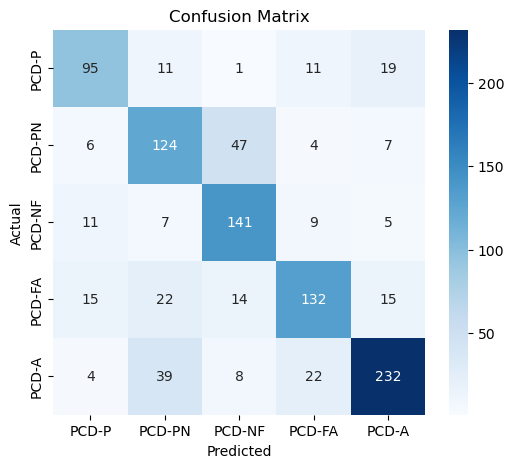

In [7]:
## Confusion matrix
cm = metrics.confusion_matrix(PCD_Subtype_NMF, PCD_Subtype_Predicted)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels = Label, yticklabels = Label)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.savefig(dir + 'Confusion_matrix.png', dpi = 300)

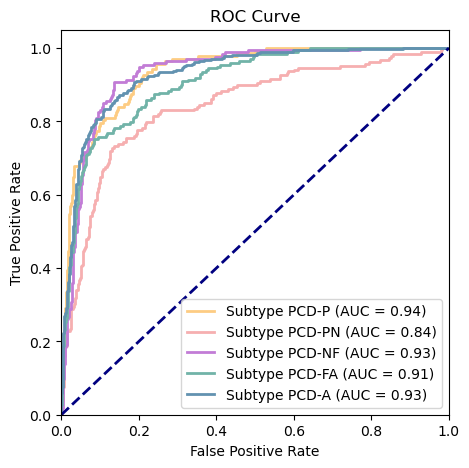

In [8]:
## ROC Curve
plt.figure(figsize = (5, 5))
lw = 2
for i in range(5):
    fpr, tpr, thresholds = metrics.roc_curve(PCD_Subtype_NMF_class[:, i], Probability[:, i], pos_label = 1)
    roc_auc = metrics.auc(fpr, tpr)
    plt.plot(fpr, tpr, lw = lw, color = cmap[Mapping1[i]], label = 'Subtype {0} (AUC = {1:0.2f})'.format(Mapping1[i], roc_auc))
plt.plot([0, 1], [0, 1], color = 'navy', lw = lw, linestyle = '--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc = "lower right")
plt.savefig(dir + 'ROC.png', dpi = 300)